In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
file_path = "sales_data.xlsx"  
df = pd.read_excel(file_path)

print("✅ Data Loaded Successfully")
print(df.head())


✅ Data Loaded Successfully
                     Date Region  Sales  Profit  Product
0 2024-05-20 08:48:58.776   East   1576     389   Tablet
1 2024-04-13 10:17:08.571   West   4493     847   Laptop
2 2024-02-21 17:08:34.286  South    879     380   Mobile
3 2024-06-04 03:25:42.857  South    992     689   Mobile
4 2024-01-26 20:34:17.143  North   2562     555  Monitor


In [3]:
def interpret_query(query: str):
    
    query = query.lower()
    
    if "average sales" in query or "avg sales" in query:
        return df.groupby("Region")["Sales"].mean()
    
    elif "total profit" in query:
        return df["Profit"].sum()
    
    elif "sales by product" in query:
        return df.groupby("Product")["Sales"].sum()
    
    elif "profit by product" in query:
        return df.groupby("Product")["Profit"].sum()
    
    elif "top 5" in query:
        return df.sort_values("Sales", ascending=False).head(5)
    
    else:
        return " Query not recognized. Try asking about sales, profit, or top products."


In [4]:
query = "show average sales by region"   # try changing this
result = interpret_query(query)

print(f"\n🔹 Query: {query}")
print("🔹 Result:\n", result)



🔹 Query: show average sales by region
🔹 Result:
 Region
East     3301.000000
North    1838.444444
South    2419.750000
West     3262.111111
Name: Sales, dtype: float64


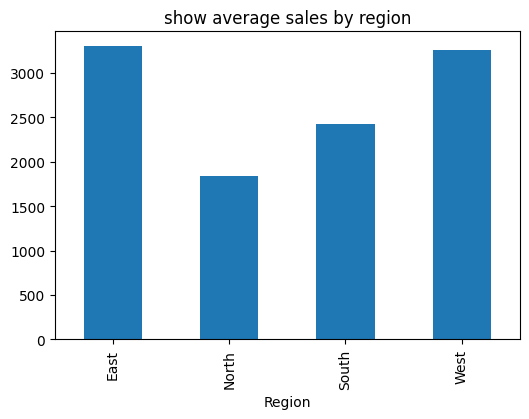

In [5]:
if isinstance(result, pd.Series) or isinstance(result, pd.DataFrame):
    result.plot(kind="bar", figsize=(6,4))
    plt.title(query)
    plt.show()

In [7]:
os.makedirs("../outputs", exist_ok=True)

if isinstance(result, (pd.Series, pd.DataFrame)):
    result.to_excel("query_result.xlsx")
    print("📂 Result exported to outputs/query_result.xlsx")

📂 Result exported to outputs/query_result.xlsx
